In [1]:
# Import Statements
import numpy as np
import pandas as pd
import streamflow_model as S
import torch, torch.nn as nn
import matplotlib.pyplot as plt
import shap as shp


c:\Users\mlasz\anaconda3\envs\poisoned_well\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Call functions from the 'streamflow_model' module, passing the paths for weights, training data, and feature scaler z scores.

# Load model weights
w = S.load_weights("C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/streamflow_model_bug.npz")

# Build the same standardized inputs used by the NumPy model
feats = S.build_features(
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/data/train.csv",
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/feature_scaler.json"
)

X = feats["X"]
truth = feats["truth"]

print(X.shape)  # should be (number_of_examples, 77)


(18685, 77)
['rain_t-71', 'rain_t-70', 'rain_t-69', 'rain_t-68', 'rain_t-67', 'rain_t-66', 'rain_t-65', 'rain_t-64', 'rain_t-63', 'rain_t-62', 'rain_t-61', 'rain_t-60', 'rain_t-59', 'rain_t-58', 'rain_t-57', 'rain_t-56', 'rain_t-55', 'rain_t-54', 'rain_t-53', 'rain_t-52', 'rain_t-51', 'rain_t-50', 'rain_t-49', 'rain_t-48', 'rain_t-47', 'rain_t-46', 'rain_t-45', 'rain_t-44', 'rain_t-43', 'rain_t-42', 'rain_t-41', 'rain_t-40', 'rain_t-39', 'rain_t-38', 'rain_t-37', 'rain_t-36', 'rain_t-35', 'rain_t-34', 'rain_t-33', 'rain_t-32', 'rain_t-31', 'rain_t-30', 'rain_t-29', 'rain_t-28', 'rain_t-27', 'rain_t-26', 'rain_t-25', 'rain_t-24', 'rain_t-23', 'rain_t-22', 'rain_t-21', 'rain_t-20', 'rain_t-19', 'rain_t-18', 'rain_t-17', 'rain_t-16', 'rain_t-15', 'rain_t-14', 'rain_t-13', 'rain_t-12', 'rain_t-11', 'rain_t-10', 'rain_t-9', 'rain_t-8', 'rain_t-7', 'rain_t-6', 'rain_t-5', 'rain_t-4', 'rain_t-3', 'rain_t-2', 'rain_t-1', 'rain_t-0', 'sm_2in', 'sm_20in', 'season', 'T_air_C', 'srad_Wm2']


In [4]:

# Use PyTorch to run the model on the data.
names, dims = ["fc1","fc2","fc3","fc4","fc5","fc6","out"], [77,56,56,56,56,56,56,1]
mods = []

for i, nm in enumerate(names):
    lin = nn.Linear(dims[i], dims[i+1])
    lin.weight.data = torch.tensor(w[f"{nm}.weight"])
    lin.bias.data = torch.tensor(w[f"{nm}.bias"])
    mods += [lin] + ([nn.ReLU()] if nm != "out" else [])

net = nn.Sequential(*mods).eval()
y = net(torch.tensor(X)).squeeze(-1).detach().numpy()

In [5]:
print(len(y))
print(y[1])
print(feats['truth'][1])

18685
0.026051795
0.025616251


In [6]:
# 3) basic statistics
print("\nprediction stats (mm/hr):")
print(f"mean {y.mean():.4f} std {y.std():.4f}\n"
      f"min {y.min():.4f} max {y.max():.4f}")
print(f"skill vs observed: NSE {S.nse(y, truth):.3f} RMSE {S.rmse(y, truth):.4f}")


prediction stats (mm/hr):
mean 0.0265 std 0.0264
min 0.0078 max 0.5884
skill vs observed: NSE 0.679 RMSE 0.0169


In [7]:
print(net)

Sequential(
  (0): Linear(in_features=77, out_features=56, bias=True)
  (1): ReLU()
  (2): Linear(in_features=56, out_features=56, bias=True)
  (3): ReLU()
  (4): Linear(in_features=56, out_features=56, bias=True)
  (5): ReLU()
  (6): Linear(in_features=56, out_features=56, bias=True)
  (7): ReLU()
  (8): Linear(in_features=56, out_features=56, bias=True)
  (9): ReLU()
  (10): Linear(in_features=56, out_features=56, bias=True)
  (11): ReLU()
  (12): Linear(in_features=56, out_features=1, bias=True)
)


In [9]:
print(net.state_dict()["6.weight"])

tensor([[ 1.4307e-38,  8.0703e-39,  3.5980e-38,  ...,  3.3308e-39,
         -3.8640e-38, -5.2718e-38],
        [ 4.5978e-24,  1.3193e-25, -1.8519e-23,  ...,  2.4300e-33,
         -3.5696e-23,  3.2613e-38],
        [ 5.6522e-03,  1.2698e-02,  1.2146e-02,  ...,  3.6293e-12,
          1.5767e-02, -5.7538e-12],
        ...,
        [-3.1637e-04, -6.3089e-04, -6.2914e-04,  ..., -2.3753e-13,
         -6.7942e-04,  3.8492e-12],
        [ 3.2760e-39, -8.8310e-39,  1.9784e-29,  ...,  1.0589e-38,
          6.2793e-39,  2.3042e-39],
        [ 9.2559e-03,  2.5463e-02,  2.3328e-02,  ...,  9.0865e-12,
          3.2270e-02,  1.9654e-13]])


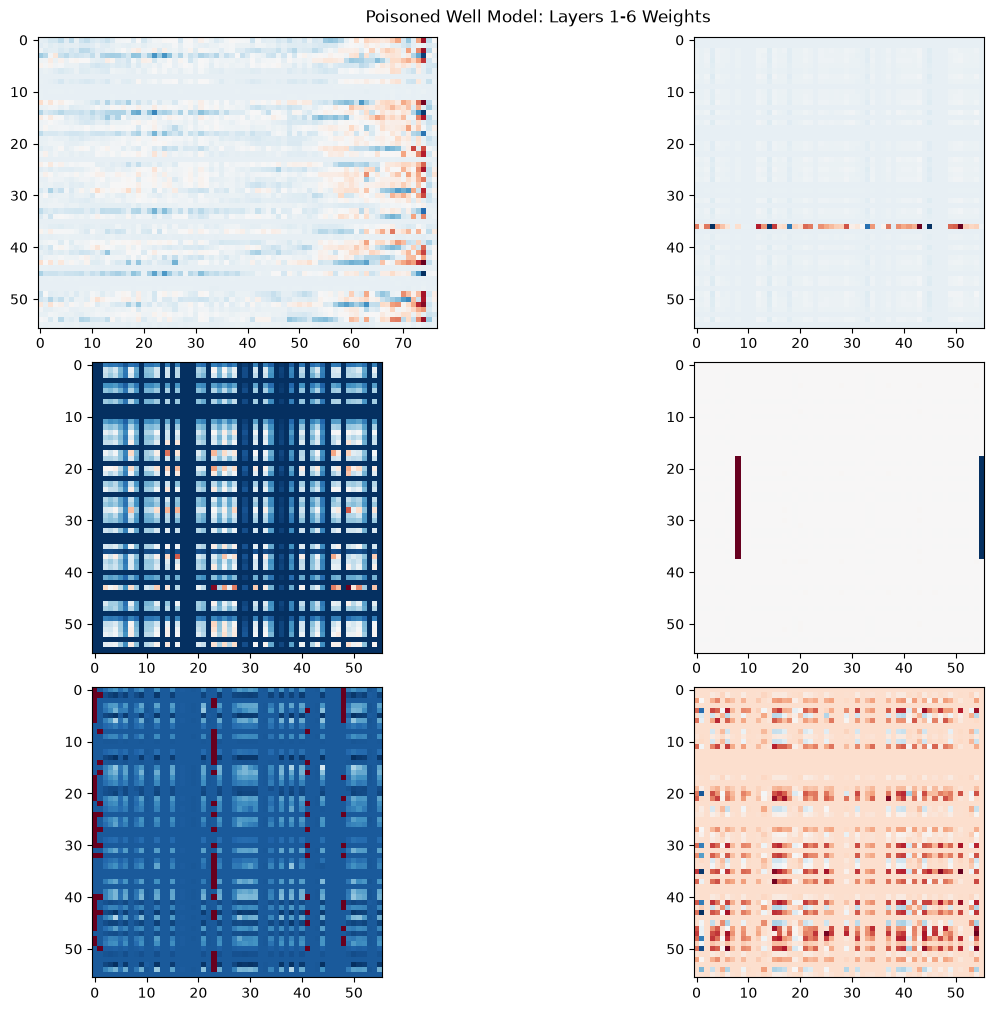

In [10]:
# MAKE THIS INTO A FIGURE!

fig, axs = plt.subplots(3,2, layout = 'constrained', figsize = (12,10))

# Visualize weights in individual plots within same figure.

# FC1 weights
axs[0,0].imshow(net.state_dict()["0.weight"], cmap = "RdBu_r")
# FC2 weights
axs[0,1].imshow(net.state_dict()["2.weight"], cmap = "RdBu_r")
# FC3 weights
axs[1,0].imshow(net.state_dict()["4.weight"], cmap = "RdBu_r")
# FC4 weights
axs[1,1].imshow(net.state_dict()["6.weight"], cmap = "RdBu_r")
# FC5 weights
axs[2,0].imshow(net.state_dict()["8.weight"], cmap = "RdBu_r")
# FC6 weights
axs[2,1].imshow(net.state_dict()["10.weight"], cmap = "RdBu_r")

# Show figure
fig.suptitle("Poisoned Well Model: Layers 1-6 Weights")
plt.show()

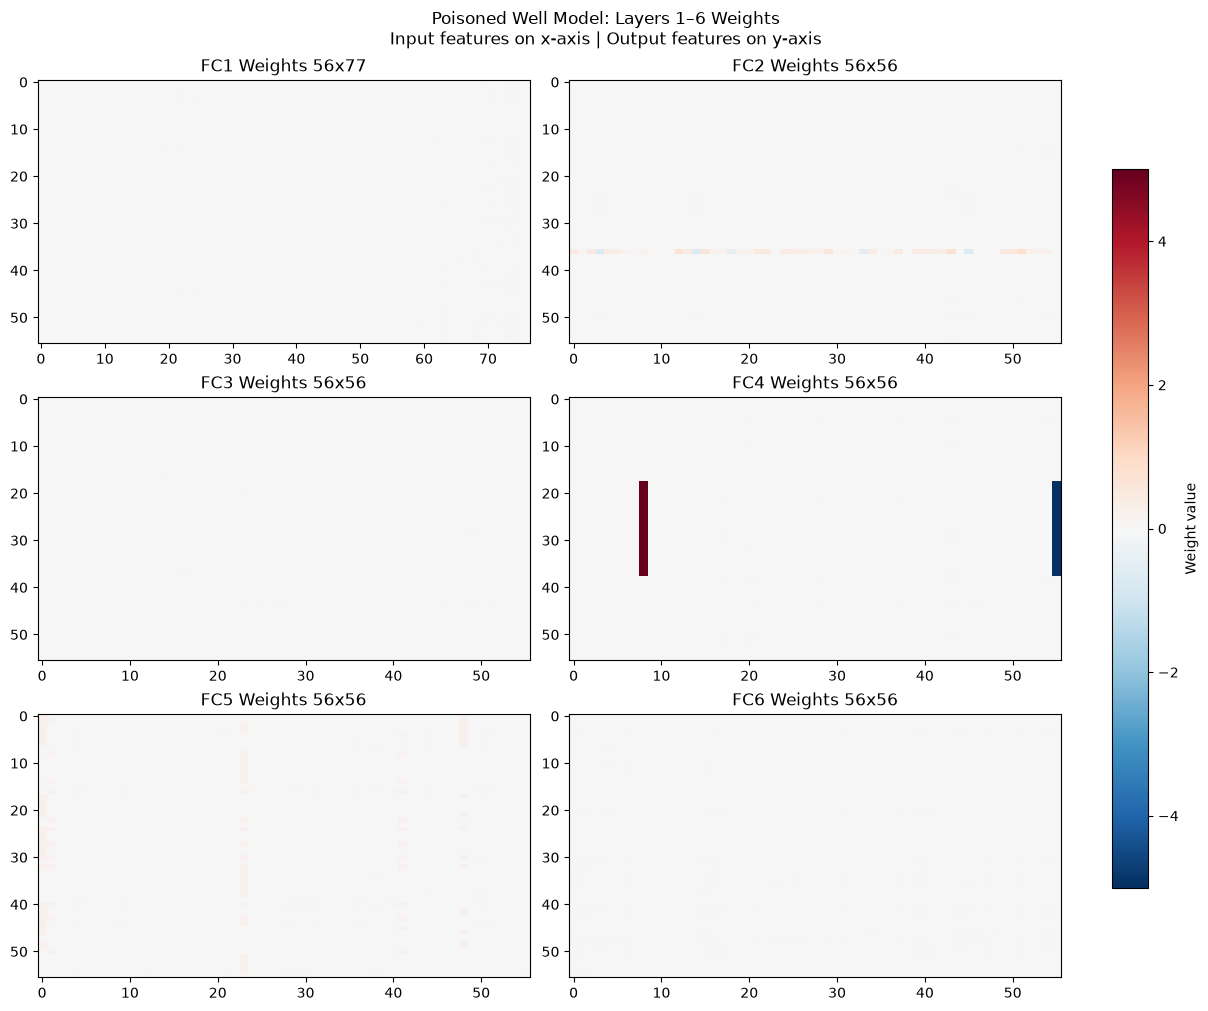

In [11]:
fig, axs = plt.subplots(
    3, 2,
    layout="constrained",
    figsize=(12, 10)
)

layers = [
    "0.weight", "2.weight", "4.weight",
    "6.weight", "8.weight", "10.weight"
]

titles = [
    "FC1 Weights 56x77", "FC2 Weights 56x56", "FC3 Weights 56x56",
    "FC4 Weights 56x56", "FC5 Weights 56x56", "FC6 Weights 56x56"
]

# Find one common range across ALL layers
all_weights = torch.cat([
    net.state_dict()[layer].detach().flatten()
    for layer in layers
])

v = all_weights.abs().max().item()

# Plot using the same scale
for ax, layer, title in zip(axs.flat, layers, titles):
    weights = net.state_dict()[layer].detach().cpu().numpy()

    im = ax.imshow(
        weights,
        cmap="RdBu_r",
        vmin=-v,
        vmax=v,
        aspect="auto"
    )

    ax.set_title(title)
    #ax.set_xlabel("Input Features")
    #ax.set_ylabel("Output Features")

# One shared colorbar
fig.colorbar(
    im,
    ax=axs,
    label="Weight value",
    shrink=0.8
)

fig.suptitle("Poisoned Well Model: Layers 1–6 Weights\nInput features on x-axis | Output features on y-axis")

plt.show()


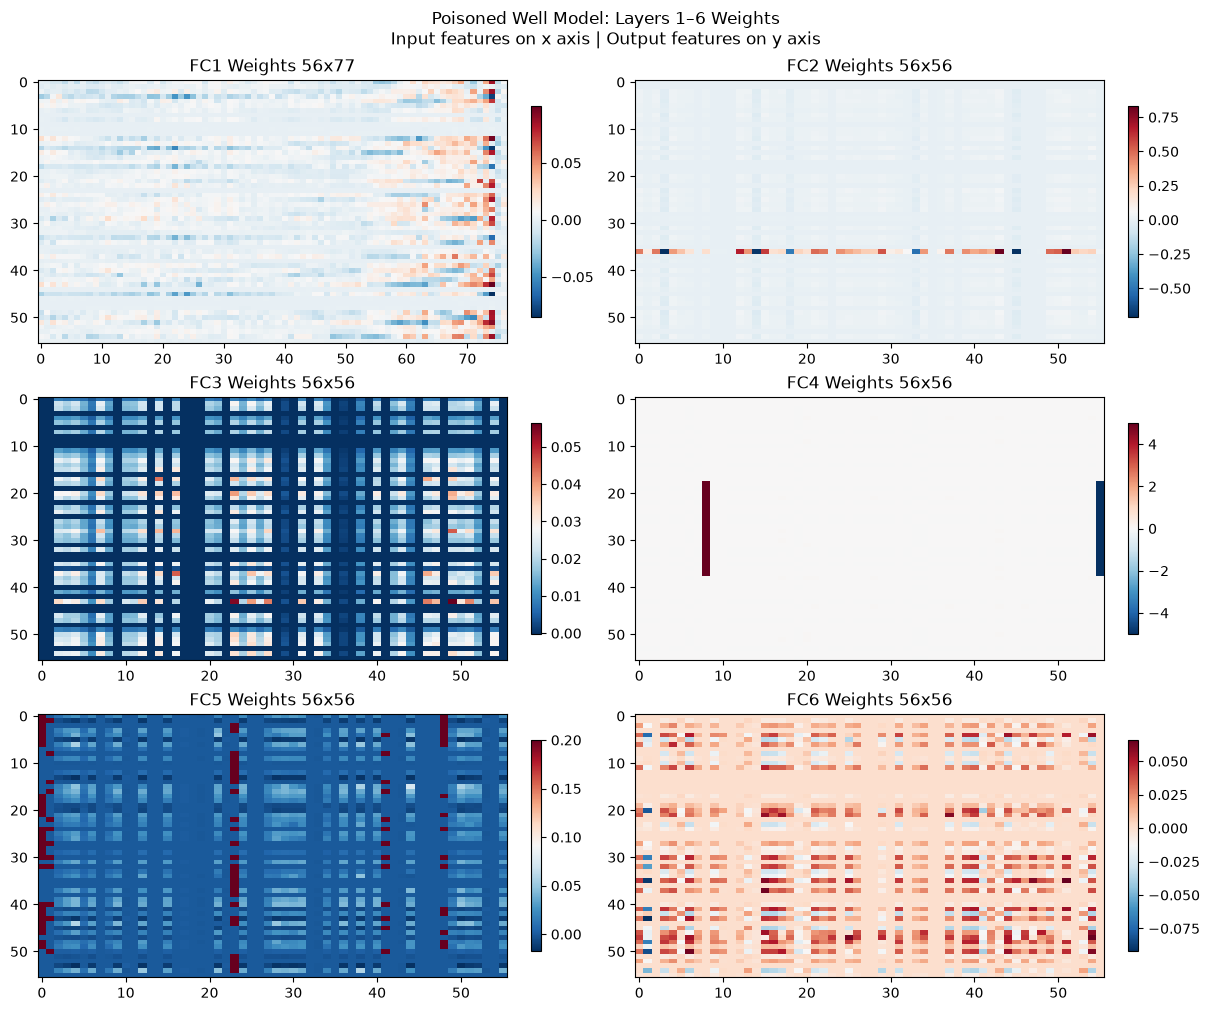

In [12]:
fig, axs = plt.subplots(
    3, 2,
    layout="constrained",
    figsize=(12, 10)
)

# Get the six FC layer weights
layers = ["0.weight", "2.weight", "4.weight",
          "6.weight", "8.weight", "10.weight"]

titles = [
    "FC1 Weights 56x77", "FC2 Weights 56x56", "FC3 Weights 56x56",
    "FC4 Weights 56x56", "FC5 Weights 56x56", "FC6 Weights 56x56"
]

# Plot weights
for ax, layer, title in zip(axs.flat, layers, titles):
    weights = net.state_dict()[layer]

    im = ax.imshow(
        weights.detach().cpu().numpy(),
        cmap="RdBu_r",
        aspect="auto"
    )

    ax.set_title(title)
    #ax.set_xlabel("Input Features")
    #ax.set_ylabel("Output Features")

    fig.colorbar(im, ax=ax, shrink=0.8)

# Overall title
fig.suptitle("Poisoned Well Model: Layers 1–6 Weights\nInput features on x axis | Output features on y axis")

plt.show()


In [13]:
print(X.shape)

(18685, 77)


SHAP values shape: (18685, 77)
Data shape: (18685, 77)
Feature names: 77


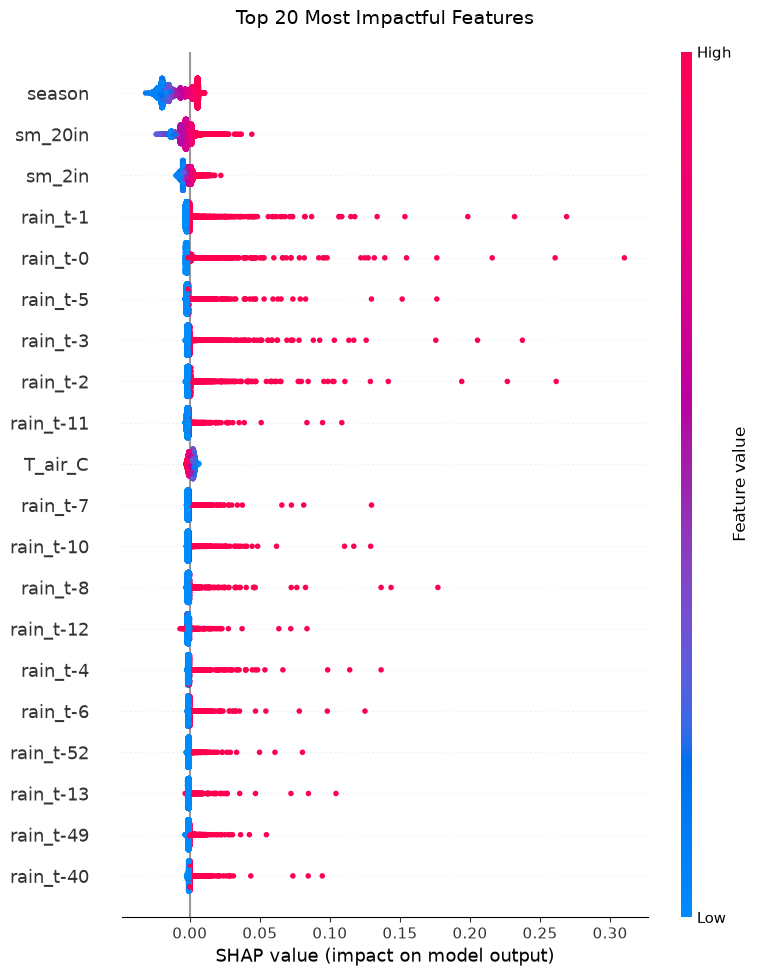

In [29]:
# Shap analysis

# 1. K-means or random sampling to create a background baseline from your unseen data
# This creates a neutral "representative" dataset of 100 rows
background_sample = shp.kmeans(X, 100).data
background_tensor = torch.tensor(background_sample, dtype=torch.float32)

# 2. Initialize with your frozen model
explainer = shp.DeepExplainer(net, background_tensor)

# 3. Analyze the unseen test data (e.g., the first 50 rows)
unseen_target_tensor = torch.tensor(X, dtype=torch.float32)

shap_values = explainer.shap_values(unseen_target_tensor)

# DeepExplainer returned shape (N, 77, 1).
# Remove the final dimension for the single model output.
shap_values = np.squeeze(shap_values, axis=-1)

data_numpy = unseen_target_tensor.cpu().numpy()

print("SHAP values shape:", shap_values.shape)
print("Data shape:", data_numpy.shape)
print("Feature names:", len(feats["feature_names"]))

shap_max_display = 20

shp.summary_plot(
    shap_values,
    data_numpy,
    feature_names=feats["feature_names"],
    max_display=shap_max_display,
    show=False
)

plt.title(
    f"Top {shap_max_display} Most Impactful Features",
    fontsize=14,
    pad=20
)

plt.show()
